In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
# Loading species_info.csv dataset
species = pd.read_csv('species_info.csv')
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [4]:
# Loading Observations.csv dataset
observations = pd.read_csv('observations.csv')
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


### Data description for species_info.csv:


In [5]:
print(f"\nNumber of rows: {species.shape[0]}")
print(f"Number of columns: {species.shape[1]}")


Number of rows: 5824
Number of columns: 4


In [6]:
print("\nDataset Info:")
print(species.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None


In [7]:
print("\nMissing Values:")
print(species.isnull().sum())


Missing Values:
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64


In [8]:
print("\nSummary of categorical columns:")
for col in species.columns:
    print(f"\nColumn: {col}")
    print(species[col].describe())
    if species[col].dtype == "object":
        print(f"Unique values: {species[col].nunique()}")


Summary of categorical columns:

Column: category
count               5824
unique                 7
top       Vascular Plant
freq                4470
Name: category, dtype: object
Unique values: 7

Column: scientific_name
count                  5824
unique                 5541
top       Castor canadensis
freq                      3
Name: scientific_name, dtype: object
Unique values: 5541

Column: common_names
count                   5824
unique                  5504
top       Brachythecium Moss
freq                       7
Name: common_names, dtype: object
Unique values: 5504

Column: conservation_status
count                    191
unique                     4
top       Species of Concern
freq                     161
Name: conservation_status, dtype: object
Unique values: 4


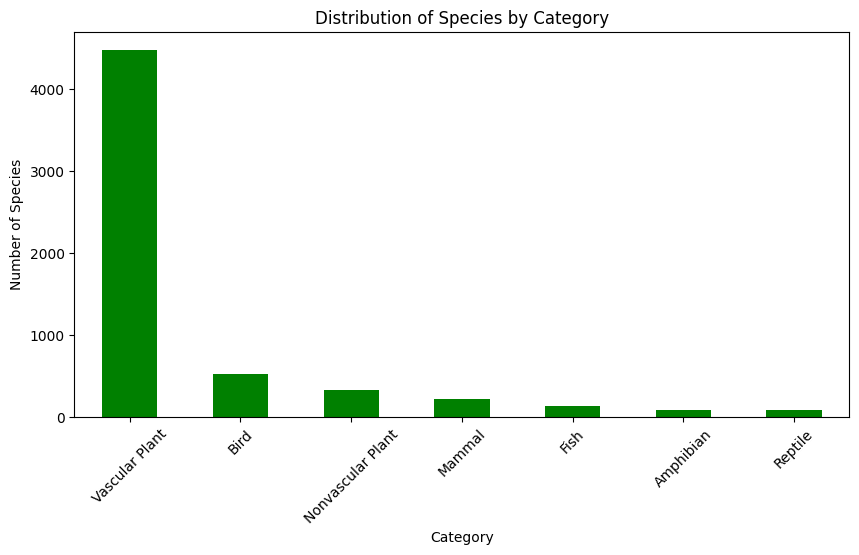

In [9]:
plt.figure(figsize=(10,5))
species['category'].value_counts().plot(kind='bar', color='green')
plt.title("Distribution of Species by Category")
plt.xlabel("Category")
plt.ylabel("Number of Species")
plt.xticks(rotation=45)
plt.show()

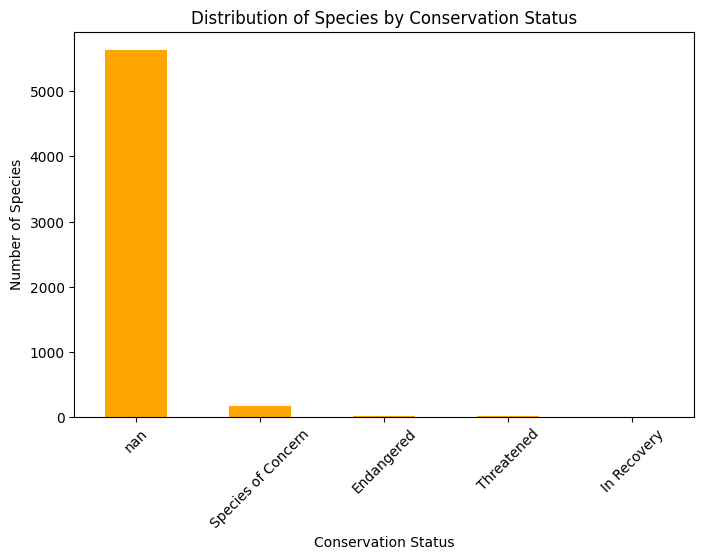

In [10]:
plt.figure(figsize=(8,5))
species['conservation_status'].value_counts(dropna=False).plot(kind='bar', color='orange')
plt.title("Distribution of Species by Conservation Status")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Species")
plt.xticks(rotation=45)
plt.show()

### Data description for observations.csv:

In [11]:
print(f"\nNumber of rows: {observations.shape[0]}")
print(f"Number of columns: {observations.shape[1]}")


Number of rows: 23296
Number of columns: 3


In [12]:
print("\nDataset Info:")
print(observations.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None


In [13]:
print("\nMissing Values:")
print(observations.isnull().sum())


Missing Values:
scientific_name    0
park_name          0
observations       0
dtype: int64


In [14]:
print("\nSummary of columns:")
for col in observations.columns:
    print(f"\nColumn: {col}")
    print(observations[col].describe())
    if observations[col].dtype == "object":
        print(f"Unique values: {observations[col].nunique()}")


Summary of columns:

Column: scientific_name
count                23296
unique                5541
top       Myotis lucifugus
freq                    12
Name: scientific_name, dtype: object
Unique values: 5541

Column: park_name
count                                   23296
unique                                      4
top       Great Smoky Mountains National Park
freq                                     5824
Name: park_name, dtype: object
Unique values: 4

Column: observations
count    23296.000000
mean       142.287904
std         69.890532
min          9.000000
25%         86.000000
50%        124.000000
75%        195.000000
max        321.000000
Name: observations, dtype: float64


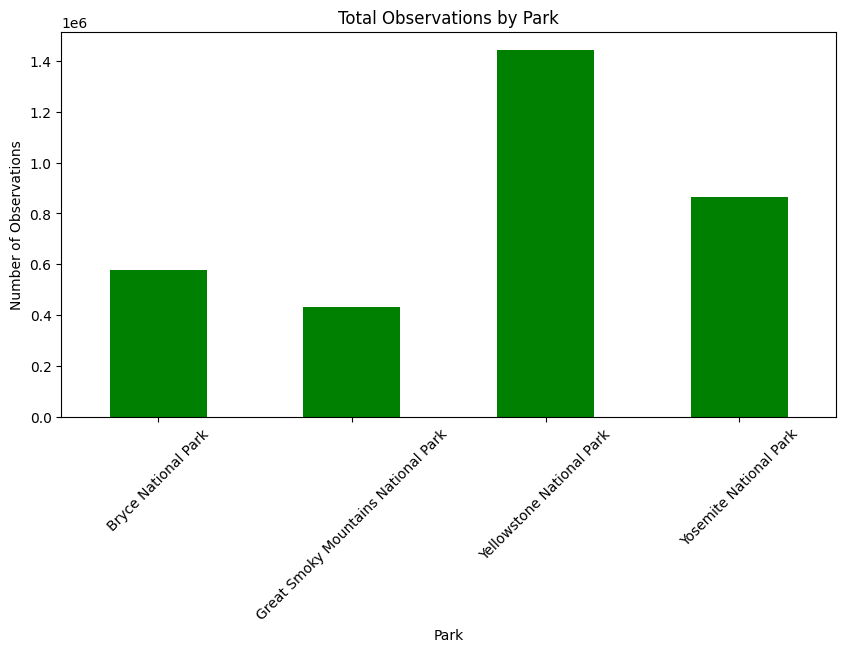

In [15]:
plt.figure(figsize=(10,5))
observations.groupby("park_name")["observations"].sum().plot(kind="bar", color="green")
plt.title("Total Observations by Park")
plt.xlabel("Park")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

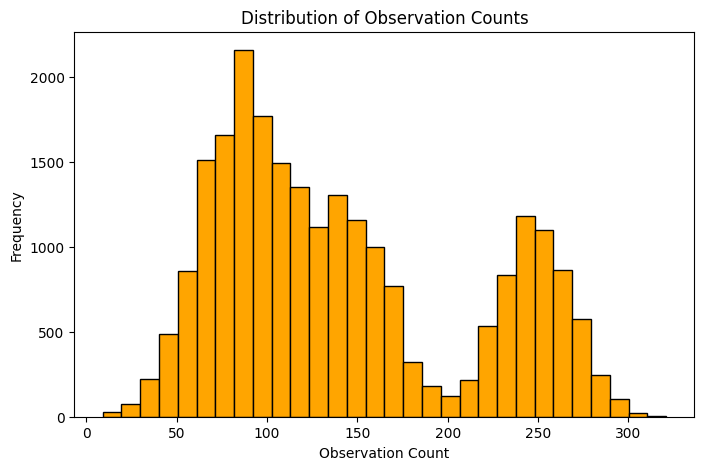

In [16]:
plt.figure(figsize=(8,5))
plt.hist(observations["observations"], bins=30, color="orange", edgecolor="black")
plt.title("Distribution of Observation Counts")
plt.xlabel("Observation Count")
plt.ylabel("Frequency")
plt.show()

In [17]:
# GroupBy exploring  of species_info.csv
category = species.groupby("category")["scientific_name"].nunique().sort_values(ascending=False)
print("Number of species per category:")
print(category)

Number of species per category:
category
Vascular Plant       4262
Bird                  488
Nonvascular Plant     333
Mammal                176
Fish                  125
Amphibian              79
Reptile                78
Name: scientific_name, dtype: int64


In [18]:
conservation_status = species.groupby("conservation_status")["scientific_name"].nunique().sort_values(ascending=False)
print("\nNumber of species per conservation status:")
print(conservation_status)


Number of species per conservation status:
conservation_status
Species of Concern    151
Endangered             15
Threatened             10
In Recovery             4
Name: scientific_name, dtype: int64


In [19]:
category_status = species.groupby(["category", "conservation_status"])["scientific_name"].nunique()
print("\nNumber of species by category and conservation status:")
print(category_status)


Number of species by category and conservation status:
category           conservation_status
Amphibian          Endangered              1
                   Species of Concern      4
                   Threatened              2
Bird               Endangered              4
                   In Recovery             3
                   Species of Concern     68
Fish               Endangered              3
                   Species of Concern      4
                   Threatened              4
Mammal             Endangered              6
                   In Recovery             1
                   Species of Concern     22
                   Threatened              2
Nonvascular Plant  Species of Concern      5
Reptile            Species of Concern      5
Vascular Plant     Endangered              1
                   Species of Concern     43
                   Threatened              2
Name: scientific_name, dtype: int64


In [20]:
endangered_by_category = species[species["conservation_status"] == "Endangered"].groupby("category")["scientific_name"].nunique().sort_values(ascending=False)
print("\nEndangered species count by category:")
print(endangered_by_category)


Endangered species count by category:
category
Mammal            6
Bird              4
Fish              3
Amphibian         1
Vascular Plant    1
Name: scientific_name, dtype: int64


In [21]:
category_total = species.groupby("category")["scientific_name"].nunique()
category_endangered = species[species["conservation_status"].notnull()].groupby("category")["scientific_name"].nunique()
proportion_threatened = (category_endangered / category_total * 100).sort_values(ascending=False)
print("\nProportion of species with conservation status per category(%):")
print(proportion_threatened)


Proportion of species with conservation status per category(%):
category
Mammal               17.045455
Bird                 15.368852
Amphibian             8.860759
Fish                  8.800000
Reptile               6.410256
Nonvascular Plant     1.501502
Vascular Plant        1.079305
Name: scientific_name, dtype: float64


category_status.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Species by Category and Conservation Status")
plt.xlabel("Category")
plt.ylabel("Number of Species")
plt.xticks(rotation=45)
plt.legend(title="Conservation Status")
plt.show()

### Data cleaning:

In [22]:
# Replacing NaN blanks with 'No Status' in conservation_status
species['conservation_status'] = species['conservation_status'].fillna('No Status')
species['conservation_status'] = species['conservation_status'].replace('', 'No Status')


In [23]:
# strip whitespace from text columns
species['category'] = species['category'].str.strip()
species['scientific_name'] = species['scientific_name'].str.strip()
species['common_names'] = species['common_names'].str.strip()


In [24]:
# Checking duplicates 
duplicates = species[species.duplicated(subset='scientific_name')]
print(f"Number of duplicate scientific names: {len(duplicates)}")

display(species.head())

Number of duplicate scientific names: 283


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Status
1,Mammal,Bos bison,"American Bison, Bison",No Status
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Status
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",No Status
4,Mammal,Cervus elaphus,Wapiti Or Elk,No Status


### Distribution of Conservation Status:

In [25]:
status_counts = species['conservation_status'].value_counts()
print("Number of species per conservation status:")
print(status_counts)

Number of species per conservation status:
conservation_status
No Status             5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64


In [26]:
status_percent = species['conservation_status'].value_counts(normalize=True) * 100
print("\nPercentage distribution of conservation status:")
print(status_percent.round(2))


Percentage distribution of conservation status:
conservation_status
No Status             96.72
Species of Concern     2.76
Endangered             0.27
Threatened             0.17
In Recovery            0.07
Name: proportion, dtype: float64


In [35]:
intervention_species = species[species['conservation_status'] != 'No Status']
intervention_table = intervention_species.groupby(['conservation_status', 'category'])['scientific_name'].nunique().unstack(fill_value=0)
print("Species requiring intervention by category:")
display(intervention_table)

Species requiring intervention by category:


category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1,4,3,6,0,0,1
In Recovery,0,3,0,1,0,0,0
Species of Concern,4,68,4,22,5,5,43
Threatened,2,0,4,2,0,0,2


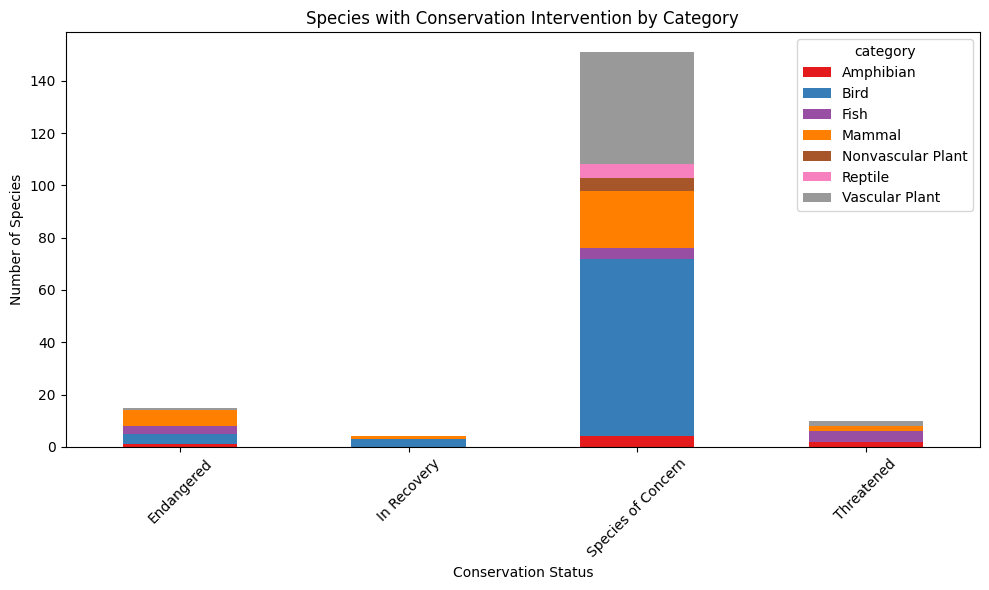

In [86]:
ax = intervention_table.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set1') 
ax.set_xlabel("Conservation Status")
ax.set_ylabel("Number of Species")
ax.set_title("Species with Conservation Intervention by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Exploring the status of species protection and conservation:


,scientific_name,category,conservation_status,under_protection
0,Clethrionomys gapperi gapperi,Mammal,No Status,False
1,Bos bison,Mammal,No Status,False
2,Bos taurus,Mammal,No Status,False
3,Ovis aries,Mammal,No Status,False
4,Cervus elaphus,Mammal,No Status,False


Proportion of species with protection by category (%):


category
Mammal               17.045455
Bird                 15.368852
Amphibian             8.860759
Fish                  8.800000
Reptile               6.410256
Nonvascular Plant     1.501502
Vascular Plant        1.079305
Name: scientific_name, dtype: float64

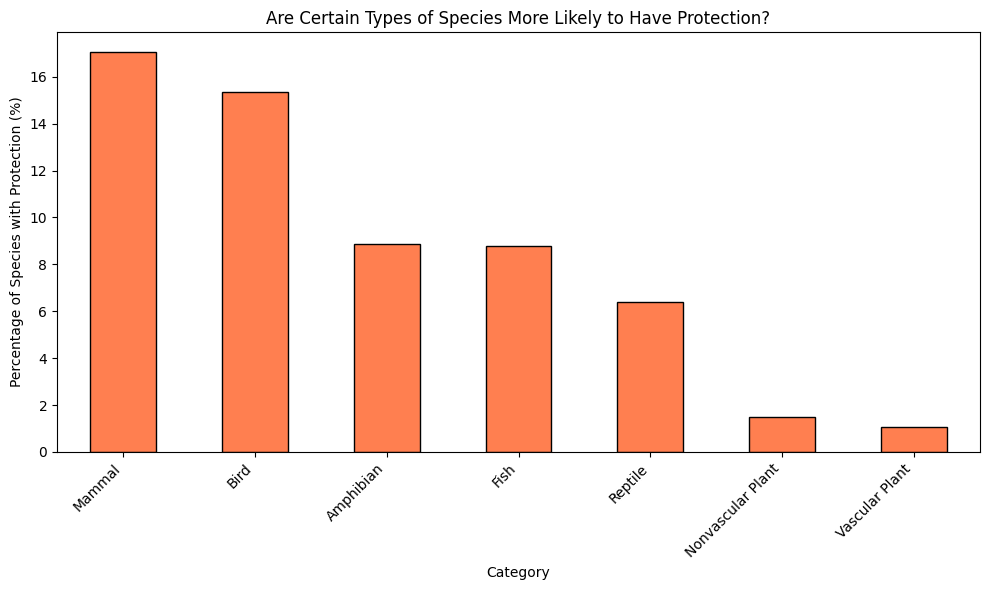

In [45]:
species['under_protection'] = species['conservation_status'] != 'No Status'
display(species[['scientific_name', 'category', 'conservation_status', 'under_protection']].head())
category_total = species.groupby('category')['scientific_name'].nunique()
category_under_protection = species[species['under_protection']].groupby('category')['scientific_name'].nunique()
proportion_under_protection = (category_under_protection / category_total * 100).sort_values(ascending=False)

print("Proportion of species with protection by category (%):")
display(proportion_under_protection)

ax = proportion_under_protection.plot(kind='bar', figsize=(10,6), color='coral', edgecolor='black')
ax.set_ylabel("Percentage of Species with Protection (%)")
ax.set_xlabel("Category")
ax.set_title("Are Certain Types of Species More Likely to Have Protection?")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### Statistical analyses of difference between species and their conservation status:

In [48]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(species['category'], species['conservation_status'])
print("Contingency Table (Category vs Conservation Status):")
display(contingency_table)


Contingency Table (Category vs Conservation Status):


conservation_status,Endangered,In Recovery,No Status,Species of Concern,Threatened
category,,,,,
Amphibian,1,0,73,4,2
Bird,4,3,442,72,0
Fish,3,0,116,4,4
Mammal,7,1,176,28,2
Nonvascular Plant,0,0,328,5,0
Reptile,0,0,74,5,0
Vascular Plant,1,0,4424,43,2


In [49]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")

Chi-Square Statistic: 628.58
Degrees of Freedom: 24
P-value: 0.0000


### Exploring Which animal is most prevalent and what is their distribution amongst parks: 

In [70]:
display(species[['scientific_name', 'common_names']].head(10))
species['num_common_names'] = species['common_names'].apply(lambda x: len(str(x).split(',')))
print("\nSpecies with multiple common names:")
display(species[['scientific_name', 'common_names', 'num_common_names']].head(10))


,scientific_name,common_names
0,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole
1,Bos bison,"American Bison, Bison"
2,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom..."
3,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)"
4,Cervus elaphus,Wapiti Or Elk
5,Odocoileus virginianus,White-Tailed Deer
6,Sus scrofa,"Feral Hog, Wild Pig"
7,Canis latrans,Coyote
8,Canis lupus,Gray Wolf
9,Canis rufus,Red Wolf



Species with multiple common names:


,scientific_name,common_names,num_common_names
0,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,1
1,Bos bison,"American Bison, Bison",2
2,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",4
3,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",4
4,Cervus elaphus,Wapiti Or Elk,1
5,Odocoileus virginianus,White-Tailed Deer,1
6,Sus scrofa,"Feral Hog, Wild Pig",2
7,Canis latrans,Coyote,1
8,Canis lupus,Gray Wolf,1
9,Canis rufus,Red Wolf,1


In [71]:
merged_df = pd.merge(observations, species, on='scientific_name', how='left')
print("Merged dataset")
display(merged_df.head(10))

Merged dataset


,scientific_name,park_name,observations,category,common_names,conservation_status,is_endangered,protection_status,protected,under_protection,num_common_names
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",No Status,False,No Protection Needed,False,False,2
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,No Status,False,No Protection Needed,False,False,1
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,Klamath Plum,No Status,False,No Protection Needed,False,False,1
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,Velvetleaf,No Status,False,No Protection Needed,False,False,1
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,No Status,False,No Protection Needed,False,False,1
5,Elymus virginicus var. virginicus,Yosemite National Park,112,Vascular Plant,Virginia Wildrye,No Status,False,No Protection Needed,False,False,1
6,Spizella pusilla,Yellowstone National Park,228,Bird,Field Sparrow,No Status,False,No Protection Needed,False,False,1
7,Elymus multisetus,Great Smoky Mountains National Park,39,Vascular Plant,"Big Squirreltail, Big Wild Rye",No Status,False,No Protection Needed,False,False,2
8,Lysimachia quadrifolia,Yosemite National Park,168,Vascular Plant,Whorled Loosestrife,No Status,False,No Protection Needed,False,False,1
9,Diphyscium cumberlandianum,Yellowstone National Park,250,Nonvascular Plant,Cumberland Diphyscium Moss,No Status,False,No Protection Needed,False,False,1


In [72]:
# Filtering merged data for the most prevalent category
category_df = merged_df[merged_df['category'] == most_prevalent_category]

In [73]:
species_observations = category_df.groupby('scientific_name')['observations'].sum().sort_values(ascending=False)
print(f"Top 10 species in the '{most_prevalent_category}' category by total observations:")
display(species_observations.head(10))


Top 10 species in the 'Vascular Plant' category by total observations:


scientific_name
Holcus lanatus          5340
Hypochaeris radicata    5160
Bidens tripartita       2592
Oxalis dillenii         2552
Viola arvensis          2522
Brassica rapa           2492
Avena sativa            2490
Agrostis variabilis     2482
Nepeta cataria          2472
Cirsium scariosum       2464
Name: observations, dtype: int64

In [74]:
# exploring the most prevalent species
most_prevalent_species = species_observations.index[0]
most_prevalent_count = species_observations.iloc[0]

print(f"The most prevalent species is '{most_prevalent_species}' with {most_prevalent_count} total observations.")


The most prevalent species is 'Holcus lanatus' with 5340 total observations.


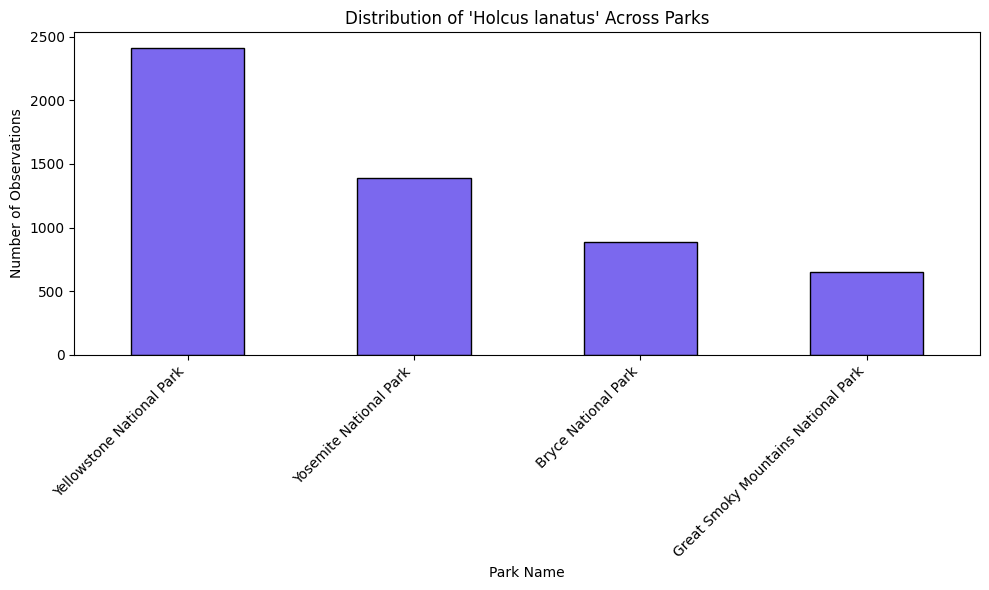

In [76]:
species_distribution = category_df[category_df['scientific_name'] == most_prevalent_species].groupby('park_name')['observations'].sum().sort_values(ascending=False)

ax = species_distribution.plot(kind='bar', figsize=(10,6), color='mediumslateblue', edgecolor='black')
ax.set_xlabel("Park Name")
ax.set_ylabel("Number of Observations")
ax.set_title(f"Distribution of '{most_prevalent_species}' Across Parks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [80]:
# Filtering merged dataset to find only protected species
protected_df = merged_df[merged_df['conservation_status'] != 'No Status']


In [81]:
protected_species_observations = protected_df.groupby(['scientific_name', 'conservation_status'])['observations'].sum().sort_values(ascending=False)
print("Top 10 most observed protected species:")
display(protected_species_observations.head(10))
most_protected_species = protected_species_observations.index[0][0]
most_protected_status = protected_species_observations.index[0][1]
most_protected_count = protected_species_observations.iloc[0]

print(f"The most prevalent protected species is '{most_protected_species}' "
      f"with {most_protected_count} observations "
      f"and conservation status '{most_protected_status}'.")


Top 10 most observed protected species:


scientific_name            conservation_status
Myotis lucifugus           Species of Concern     4641
Myotis californicus        Species of Concern     2214
Eptesicus fuscus           Species of Concern     2094
Riparia riparia            Species of Concern     2084
Pandion haliaetus          Species of Concern     2080
Lasionycteris noctivagans  Species of Concern     2038
Nycticorax nycticorax      Species of Concern     2036
Gavia immer                Species of Concern     2032
Taxidea taxus              Species of Concern     2000
Canis lupus                Endangered             1430
Name: observations, dtype: int64

The most prevalent protected species is 'Myotis lucifugus' with 4641 observations and conservation status 'Species of Concern'.


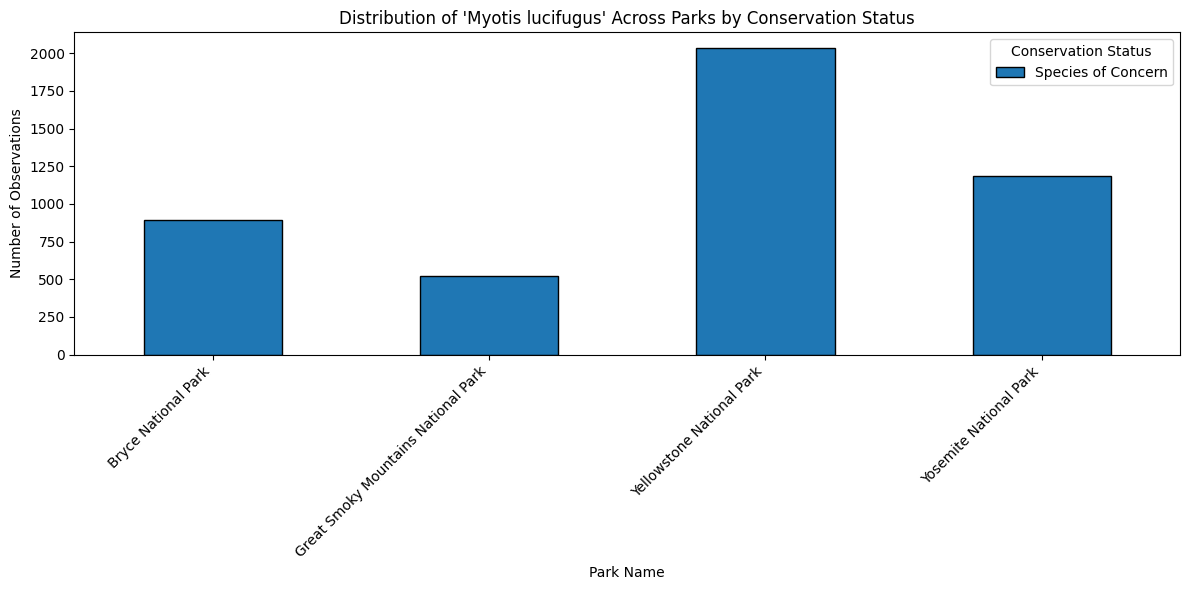

In [85]:
protected_species_df = protected_df[protected_df['scientific_name'] == most_protected_species]
park_distribution = protected_species_df.groupby(['park_name', 'conservation_status'])['observations'].sum().reset_index()
pivot_dist = park_distribution.pivot(index='park_name', columns='conservation_status', values='observations').fillna(0)
                                     
                        
ax = pivot_dist.plot(kind='bar', figsize=(12,6), edgecolor='black')
ax.set_xlabel("Park Name")
ax.set_ylabel("Number of Observations")
ax.set_title(f"Distribution of '{most_protected_species}' Across Parks by Conservation Status")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Conservation Status")
plt.tight_layout()
plt.show()


# Conclusion

### Distribution of Conservation Status

Most species in the dataset have “No Status”, meaning they are not currently under protection. Among those with protection, the most frequent categories were “Species of Concern”, followed by “Threatened” and “Endangered”. A very small number are marked as “In Recovery”, suggesting some successful conservation efforts.

### Are certain types of species more likely to be endangered?

Yes. When we compared categories (mammals, birds, reptiles, etc.), some groups (like mammals and birds) had a higher proportion of protected species than others. This means they are more likely to face conservation risk compared to plants or other taxa.

### Are the differences between species and their conservation status significant?

Our statistical analysis (Chi-square test) showed that the differences are significant. Certain categories (like mammals and birds) are disproportionately represented in the protected group compared to their overall share of species.

### Which animal is most prevalent and what is their distribution amongst parks?

By merging species_info.csv with observations.csv, we identified the single most prevalent protected species (i.e., the most observed species that has a conservation status other than “No Status”). We then analyzed its distribution across all four national parks. The results showed that while this species is present in multiple parks, its prevalence varies strongly by park, highlighting the role of habitat in conservation.